tqdm进度条工具安装与使用

- 工具安装：需要通过pip install tqdm命令在Python虚拟环境中安装该模块，安装完成后才能导入使用。
- 使用方法：通过`from tqdm import tqdm`导入后，将tqdm包裹for循环遍历的DataLoader即可生成进度条。
- 使用限制：for循环内部不能添加任何print输出语句，否则会打乱进度条格式，若需要输出损失建议在循环外输出平均损失。
- 作用：可以直观展示数据加载进度、已消耗时间和剩余等待时间，解决训练时无法判断当前执行进度的问题。

模型参数与超参数的概念区分

- 模型参数定义：神经网络中需要学习调整的权重w和偏移量b属于模型参数，是网络本身自带的可训练参数。
- 超参数定义：所有用于调整模型参数w和b的外部参数都属于超参数，不属于神经网络本身结构。
- 常见超参数举例：学习率、batch size、训练迭代次数Epochs、网络层数、输入输出特征尺寸都属于超参数。
- YOLO系列框架超参数示例：YOLOv5通过n/s/m/l/x不同尺码配置文件控制网络层数和通道数，全部配置都属于超参数，YOLOv8的default配置文件包含了上百种超参数设置。

In [1]:
# ============================================================
# 单元格 1：数据集类 + 网络结构定义
# ============================================================

import numpy as np
import struct
import os
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# ==================== MNISTDataset：从 IDX 文件加载数据 ====================
class MNISTDataset(Dataset):
    """
    将 IDX 二进制文件封装为 PyTorch Dataset
    支持 tqdm 进度条、标签格式可选（整数 / one-hot）
    """
    def __init__(self, data_dir=r"D:\Medicaldata\MNIST\raw", train=True, label_mode='int'):
        """
        label_mode: 'int'   → 返回整数标签 (用于 CrossEntropyLoss)
                    'onehot' → 返回 one-hot 标签 (用于 MSELoss)
        """
        super().__init__()
        self.label_mode = label_mode

        # 构造文件路径
        if train:
            images_file = os.path.join(data_dir, "train-images-idx3-ubyte")
            labels_file = os.path.join(data_dir, "train-labels-idx1-ubyte")
            prefix = "训练集"
        else:
            images_file = os.path.join(data_dir, "t10k-images-idx3-ubyte")
            labels_file = os.path.join(data_dir, "t10k-labels-idx1-ubyte")
            prefix = "测试集"

        print(f"{'='*40}")
        print(f"  加载 {prefix}")
        print(f"{'='*40}")

        # 读取图像
        self.images = self._read_idx_images(images_file)
        # 读取标签
        self.labels = self._read_idx_labels(labels_file)

        # 归一化并转为 Tensor（在 __init__ 中一次性完成，训练时更快）
        self.images = torch.tensor(self.images.astype(np.float32) / 255.0).reshape(-1, 28 * 28)
        if label_mode == 'int':
            self.labels = torch.tensor(self.labels.astype(np.int64))
        else:
            self.labels = F.one_hot(torch.tensor(self.labels, dtype=torch.int64), 10).float()

        print(f"\n✅ 加载完成! 共 {len(self.images)} 个样本")
        print(f"   图像形状: {self.images.shape}, 标签形状: {self.labels.shape}")

    def _read_idx_images(self, filepath):
        """读取 IDX 图像文件"""
        with open(filepath, 'rb') as f:
            magic, num_images, rows, cols = struct.unpack('>IIII', f.read(16))
            assert magic == 2051, f"魔术数字错误: {magic}，应为2051"
            image_size = rows * cols
            print(f"正在加载 {num_images} 张图片 ({rows}x{cols})...")
            images = np.zeros((num_images, rows, cols), dtype=np.uint8)
            for i in tqdm(range(num_images), desc="加载进度", unit="张"):
                images[i] = np.frombuffer(f.read(image_size), dtype=np.uint8).reshape(rows, cols)
            return images

    def _read_idx_labels(self, filepath):
        """读取 IDX 标签文件"""
        with open(filepath, 'rb') as f:
            magic, num_labels = struct.unpack('>II', f.read(8))
            assert magic == 2049, f"魔术数字错误: {magic}，应为2049"
            print(f"正在加载 {num_labels} 个标签...")
            labels = np.zeros(num_labels, dtype=np.uint8)
            for i in tqdm(range(num_labels), desc="加载进度", unit="个"):
                labels[i] = struct.unpack('B', f.read(1))[0]
            return labels

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]

# ==================== 网络结构 ====================
class ThreeLayerFCNet(nn.Module):
    """三层全连接网络（输出 logits，配合 CrossEntropyLoss 使用）"""
    def __init__(self, input_dim=784, hidden1=512, hidden2=256, num_classes=10):
        super().__init__()
        self.fc1   = nn.Linear(input_dim, hidden1)
        self.relu1 = nn.ReLU()
        self.fc2   = nn.Linear(hidden1, hidden2)
        self.relu2 = nn.ReLU()
        self.fc3   = nn.Linear(hidden2, num_classes)

    def forward(self, x):
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        return self.fc3(x)          # 输出 logits（不加 Softmax）

class ThreeLayerFCNet_MSE(nn.Module):
    """三层全连接网络 + Softmax（配合 MSELoss 使用）"""
    def __init__(self, input_dim=784, hidden1=512, hidden2=256, num_classes=10):
        super().__init__()
        self.fc1     = nn.Linear(input_dim, hidden1)
        self.relu1   = nn.ReLU()
        self.fc2     = nn.Linear(hidden1, hidden2)
        self.relu2   = nn.ReLU()
        self.fc3     = nn.Linear(hidden2, num_classes)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        return self.softmax(self.fc3(x))   # 输出概率


MINIST数据集加载代码回顾

- 数据集加载步骤：从torchvision导入datasets，指定数据集存储路径，设置train=True加载训练集，添加transforms.ToTensor完成数据预处理。
- DataLoader设置：将加载好的数据集传入DataLoader，本次示例设置batch size为2000，设置shuffle=True打乱数据集顺序。
- 原有遍历问题：直接遍历输出每个batch的shape时，无法知道遍历进度和剩余时间，需要借助进度条工具优化。

自定义MINIST分类神经网络设计

- 网络结构设计：继承torch.nn.Module搭建网络，使用Sequential时序容器封装网络层，结构为：展平层 → 全连接层(784→512) → ReLU激活 → 全连接层(512→128) → ReLU激活 → 全连接层(128→64) → 全连接层(64→10) → Softmax(dim=1)。
- 输入形状调整：输入数据默认是四维NCHW格式，需要添加展平层将其转换为二维NV格式，适配全连接层的输入要求。
- 网络层获取与修改：可以通过net.layers[索引]获取指定层，常用于修改预训练网络的输入层特征数或输出层分类数，适配新的数据集。

神经网络参数量计算方法

- 手动计算规则：全连接层参数量 = 输入特征数 × 输出特征数（w的数量） + 输出特征数（b的数量），激活函数和展平层没有可训练参数。
- 自动统计工具安装：需要安装第三方模块torchsummary，通过该模块可以自动统计每一层和整个网络的参数量。
- 工具调用方法：导入summary函数后，传入搭建好的模型、输入尺寸元组、batch size和运行设备（CPU/GPU）即可输出统计结果。
- 本次示例统计结果：本次搭建的针对MINIST数据集的网络总参数量约为47万，对于简单的MINIST分类任务来说参数量偏多。

In [2]:
# ============================================================
# 单元格 2：Trainer 类 — 封装训练与评估的完整流程
# ============================================================

import os
import matplotlib.pyplot as plt
import matplotlib

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'SimSun']
plt.rcParams['axes.unicode_minus'] = False

class Trainer:
    """
    通用模型训练器
    支持 CrossEntropyLoss / MSELoss，自动保存最优模型，记录训练曲线
    """
    def __init__(self, net, train_loader, test_loader,
                 loss_fn=nn.CrossEntropyLoss(), lr=0.001,
                 save_dir='checkpoints', model_name='model'):
        # ----- 设备 -----
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        # ----- 网络 -----
        self.net = net.to(self.device)
        # ----- 数据 -----
        self.train_loader = train_loader
        self.test_loader  = test_loader
        # ----- 损失 & 优化器 -----
        self.loss_fn = loss_fn
        self.opt = torch.optim.Adam(self.net.parameters(), lr=lr)
        # ----- 模型保存 -----
        self.save_dir = save_dir
        self.model_name = model_name
        os.makedirs(save_dir, exist_ok=True)
        # ----- 历史记录 -----
        self.train_losses = []
        self.test_losses  = []
        self.train_accs   = []
        self.test_accs    = []
        self.best_acc = 0.0
        # ----- 当前 epoch -----
        self.epoch = 0

        self._is_mse = isinstance(loss_fn, nn.MSELoss)

        print(f"使用设备: {self.device}")
        print(f"损失函数: {type(loss_fn).__name__}")
        print(self.net)

    # ==================== 训练一个 Epoch ====================
    def _train_one_epoch(self):
        self.net.train()
        running_loss = 0.0
        correct = 0
        total = 0

        pbar = tqdm(self.train_loader, desc=f"Epoch {self.epoch}", unit="batch")
        for inputs, targets in pbar:
            inputs = inputs.to(self.device)
            targets = targets.to(self.device)

            # MSE 时 labels 已经是 one-hot float
            if not self._is_mse:
                targets = targets.long()

            self.opt.zero_grad()
            outputs = self.net(inputs)
            loss = self.loss_fn(outputs, targets)
            loss.backward()
            self.opt.step()

            running_loss += loss.item() * inputs.size(0)

            # 准确率计算（兼容 int 和 one-hot）
            _, predicted = outputs.max(1)
            if self._is_mse:
                _, true_cls = targets.max(1)
            else:
                true_cls = targets
            total += targets.size(0)
            correct += predicted.eq(true_cls).sum().item()

            pbar.set_postfix(loss=loss.item(), acc=100.0 * correct / total)

        return running_loss / len(self.train_loader.dataset), 100.0 * correct / total

    # ==================== 评估 ====================
    @torch.no_grad()
    def _evaluate(self):
        self.net.eval()
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, targets in self.test_loader:
            inputs = inputs.to(self.device)
            targets = targets.to(self.device)
            if not self._is_mse:
                targets = targets.long()

            outputs = self.net(inputs)
            loss = self.loss_fn(outputs, targets)
            running_loss += loss.item() * inputs.size(0)

            _, predicted = outputs.max(1)
            if self._is_mse:
                _, true_cls = targets.max(1)
            else:
                true_cls = targets
            total += targets.size(0)
            correct += predicted.eq(true_cls).sum().item()

        return running_loss / len(self.test_loader.dataset), 100.0 * correct / total

    # ==================== 完整训练 ====================
    def fit(self, num_epochs=10, plot=True):
        print(f"\n{'='*40}")
        print(f"  开始训练，共 {num_epochs} 个 Epoch")
        print(f"{'='*40}\n")

        for epoch in range(1, num_epochs + 1):
            self.epoch = epoch

            train_loss, train_acc = self._train_one_epoch()
            test_loss,  test_acc  = self._evaluate()

            self.train_losses.append(train_loss)
            self.train_accs.append(train_acc)
            self.test_losses.append(test_loss)
            self.test_accs.append(test_acc)

            # 自动保存最优模型
            if test_acc > self.best_acc:
                self.best_acc = test_acc
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': self.net.state_dict(),
                    'optimizer_state_dict': self.opt.state_dict(),
                    'test_acc': self.best_acc,
                }, os.path.join(self.save_dir, f'best_{self.model_name}.pth'))
                print(f"  训练  Loss: {train_loss:.4f}  Acc: {train_acc:.2f}%  |  "
                      f"测试  Loss: {test_loss:.4f}  Acc: {test_acc:.2f}%  ⭐ 已保存最优模型\n")
            else:
                print(f"  训练  Loss: {train_loss:.4f}  Acc: {train_acc:.2f}%  |  "
                      f"测试  Loss: {test_loss:.4f}  Acc: {test_acc:.2f}%\n")

        print(f"\n🎉 训练完成！最佳测试准确率: {self.best_acc:.2f}%")
        print(f"   最优模型已保存至 {self.save_dir}/best_{self.model_name}.pth")

        if plot:
            self._plot_curves()

    # ==================== 绘制曲线 ====================
    def _plot_curves(self):
        epochs = range(1, self.epoch + 1)
        plt.figure(figsize=(12, 4))

        plt.subplot(1, 2, 1)
        plt.plot(epochs, self.train_losses, 'b-o', label='训练 Loss')
        plt.plot(epochs, self.test_losses,  'r-o', label='测试 Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.title(f'Loss 曲线 ({self.model_name})')

        plt.subplot(1, 2, 2)
        plt.plot(epochs, self.train_accs, 'b-o', label='训练 Acc')
        plt.plot(epochs, self.test_accs,  'r-o', label='测试 Acc')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy (%)')
        plt.legend()
        plt.title(f'准确率曲线 ({self.model_name})')

        plt.tight_layout()
        plt.show()

    # ==================== 加载已保存的模型 ====================
    def load_best(self):
        pth = os.path.join(self.save_dir, f'best_{self.model_name}.pth')
        if os.path.exists(pth):
            ckpt = torch.load(pth, map_location=self.device, weights_only=False)
            self.net.load_state_dict(ckpt['model_state_dict'])
            self.best_acc = ckpt['test_acc']
            print(f"已加载最优模型 (epoch {ckpt['epoch']}, acc={self.best_acc:.2f}%)")
        else:
            print(f"未找到模型文件: {pth}")


  加载 训练集
正在加载 60000 张图片 (28x28)...


加载进度:   0%|          | 0/60000 [00:00<?, ?张/s]

加载进度: 100%|██████████| 60000/60000 [00:00<00:00, 463117.00张/s]


正在加载 60000 个标签...


加载进度: 100%|██████████| 60000/60000 [00:00<00:00, 2610860.58个/s]


...

  训练  Loss: 0.0173  Acc: 99.39%  |  测试  Loss: 0.0770  Acc: 98.11%  ⭐ 已保存最优模型



Epoch 9: 100%|██████████| 938/938 [00:04<00:00, 205.44batch/s, acc=99.4, loss=5.23e-5] 


  训练  Loss: 0.0168  Acc: 99.44%  |  测试  Loss: 0.0806  Acc: 98.12%  ⭐ 已保存最优模型



Epoch 10: 100%|██████████| 938/938 [00:04<00:00, 206.63batch/s, acc=99.5, loss=0.0059]  


  训练  Loss: 0.0139  Acc: 99.54%  |  测试  Loss: 0.0808  Acc: 98.13%  ⭐ 已保存最优模型


🎉 训练完成！最佳测试准确率: 98.13%
   最优模型已保存至 checkpoints/best_model_ce.pth


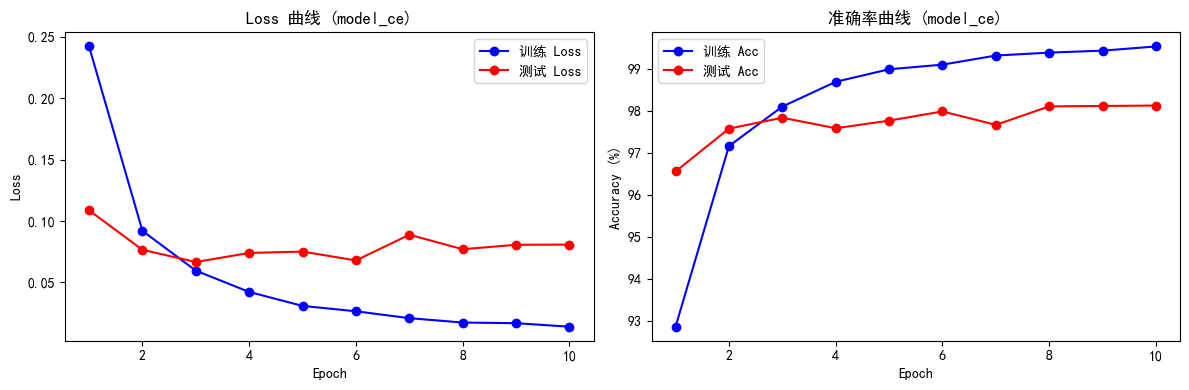

  加载 训练集
正在加载 60000 张图片 (28x28)...


加载进度: 100%|██████████| 60000/60000 [00:00<00:00, 515413.23张/s]


正在加载 60000 个标签...


加载进度: 100%|██████████| 60000/60000 [00:00<00:00, 2958457.63个/s]



✅ 加载完成! 共 60000 个样本
   图像形状: torch.Size([60000, 784]), 标签形状: torch.Size([60000, 10])
  加载 测试集
正在加载 10000 张图片 (28x28)...


...

  训练  Loss: 0.0017  Acc: 98.97%  |  测试  Loss: 0.0036  Acc: 97.75%  ⭐ 已保存最优模型



Epoch 9: 100%|██████████| 938/938 [00:05<00:00, 186.65batch/s, acc=99, loss=3.18e-7]   


  训练  Loss: 0.0017  Acc: 98.97%  |  测试  Loss: 0.0036  Acc: 97.73%



Epoch 10: 100%|██████████| 938/938 [00:05<00:00, 184.48batch/s, acc=99.2, loss=0.00649] 


  训练  Loss: 0.0014  Acc: 99.15%  |  测试  Loss: 0.0030  Acc: 98.16%  ⭐ 已保存最优模型


🎉 训练完成！最佳测试准确率: 98.16%
   最优模型已保存至 checkpoints/best_model_mse.pth


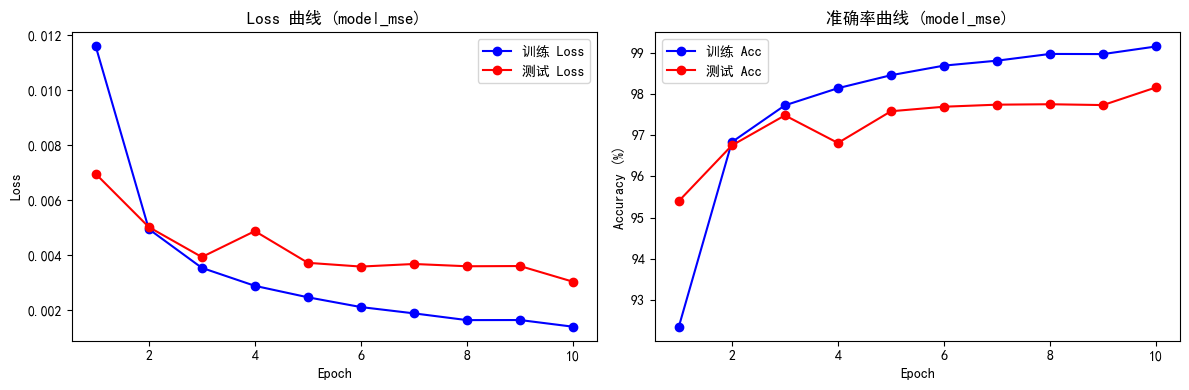


  CE  最佳测试准确率: 98.13%
  MSE 最佳测试准确率: 98.16%


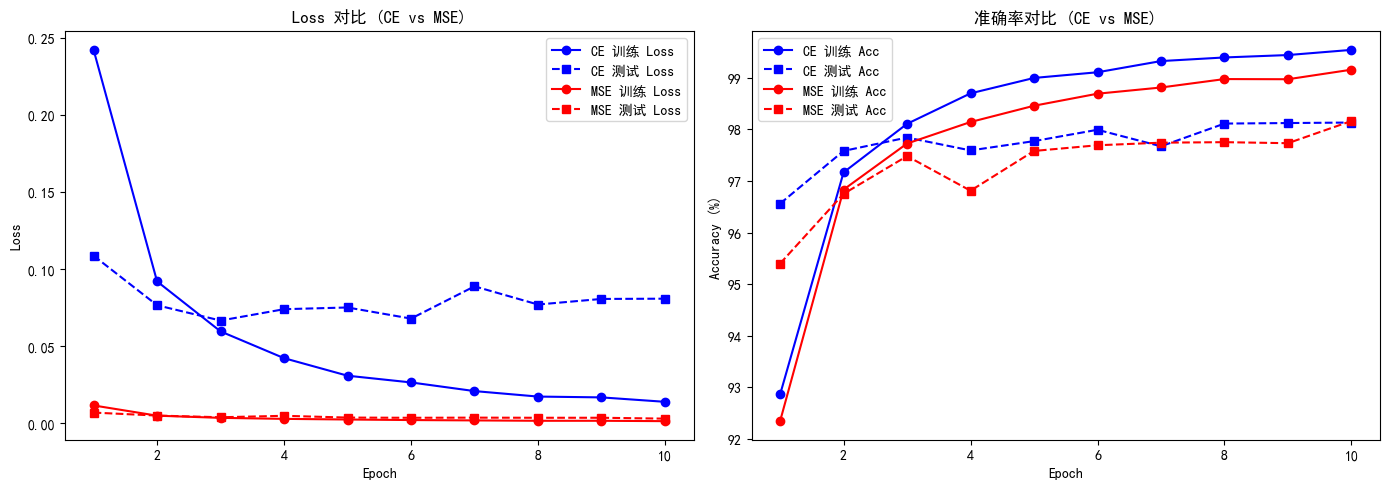

In [3]:
# ============================================================
# 单元格 3：创建 DataLoader + 执行 CE / MSE 训练
# ============================================================

# ==================== 1. 创建 DataLoader ====================
batch_size = 64

train_dataset = MNISTDataset(train=True, label_mode='int')
test_dataset  = MNISTDataset(train=False, label_mode='int')

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

print(f"\n训练样本: {len(train_dataset)}, 测试样本: {len(test_dataset)}")
print(f"输入维度: {train_dataset.images.shape[1]}, 输出类别: 10\n")

# ==================== 2. 训练 CE 模型 ====================
net_ce = ThreeLayerFCNet()
trainer_ce = Trainer(
    net=net_ce,
    train_loader=train_loader,
    test_loader=test_loader,
    loss_fn=nn.CrossEntropyLoss(),
    model_name='model_ce'
)
trainer_ce.fit(num_epochs=10)

# ==================== 3. 训练 MSE 模型 ====================
# MSE 需要标签为 one-hot，重新创建数据集
train_dataset_mse = MNISTDataset(train=True, label_mode='onehot')
test_dataset_mse  = MNISTDataset(train=False, label_mode='onehot')

train_loader_mse = DataLoader(train_dataset_mse, batch_size=batch_size, shuffle=True)
test_loader_mse  = DataLoader(test_dataset_mse,  batch_size=batch_size, shuffle=False)

net_mse = ThreeLayerFCNet_MSE()
trainer_mse = Trainer(
    net=net_mse,
    train_loader=train_loader_mse,
    test_loader=test_loader_mse,
    loss_fn=nn.MSELoss(),
    model_name='model_mse'
)
trainer_mse.fit(num_epochs=10)

# ==================== 4. 对比汇总 ====================
print(f"\n{'='*50}")
print(f"  CE  最佳测试准确率: {trainer_ce.best_acc:.2f}%")
print(f"  MSE 最佳测试准确率: {trainer_mse.best_acc:.2f}%")
print(f"{'='*50}")

# ==================== 5. 对比曲线 ====================
epochs = range(1, trainer_ce.epoch + 1)
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, trainer_ce.train_losses,  'b-o', label='CE 训练 Loss')
plt.plot(epochs, trainer_ce.test_losses,   'b--s', label='CE 测试 Loss')
plt.plot(epochs, trainer_mse.train_losses, 'r-o', label='MSE 训练 Loss')
plt.plot(epochs, trainer_mse.test_losses,  'r--s', label='MSE 测试 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss 对比 (CE vs MSE)')

plt.subplot(1, 2, 2)
plt.plot(epochs, trainer_ce.train_accs,  'b-o', label='CE 训练 Acc')
plt.plot(epochs, trainer_ce.test_accs,   'b--s', label='CE 测试 Acc')
plt.plot(epochs, trainer_mse.train_accs, 'r-o', label='MSE 训练 Acc')
plt.plot(epochs, trainer_mse.test_accs,  'r--s', label='MSE 测试 Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.title('准确率对比 (CE vs MSE)')

plt.tight_layout()
plt.show()


已加载最优模型 (epoch 10, acc=98.13%)
已加载最优模型 (epoch 10, acc=98.16%)

加载后评估准确率:
  CE 模型:  98.13%
  MSE 模型: 98.16%


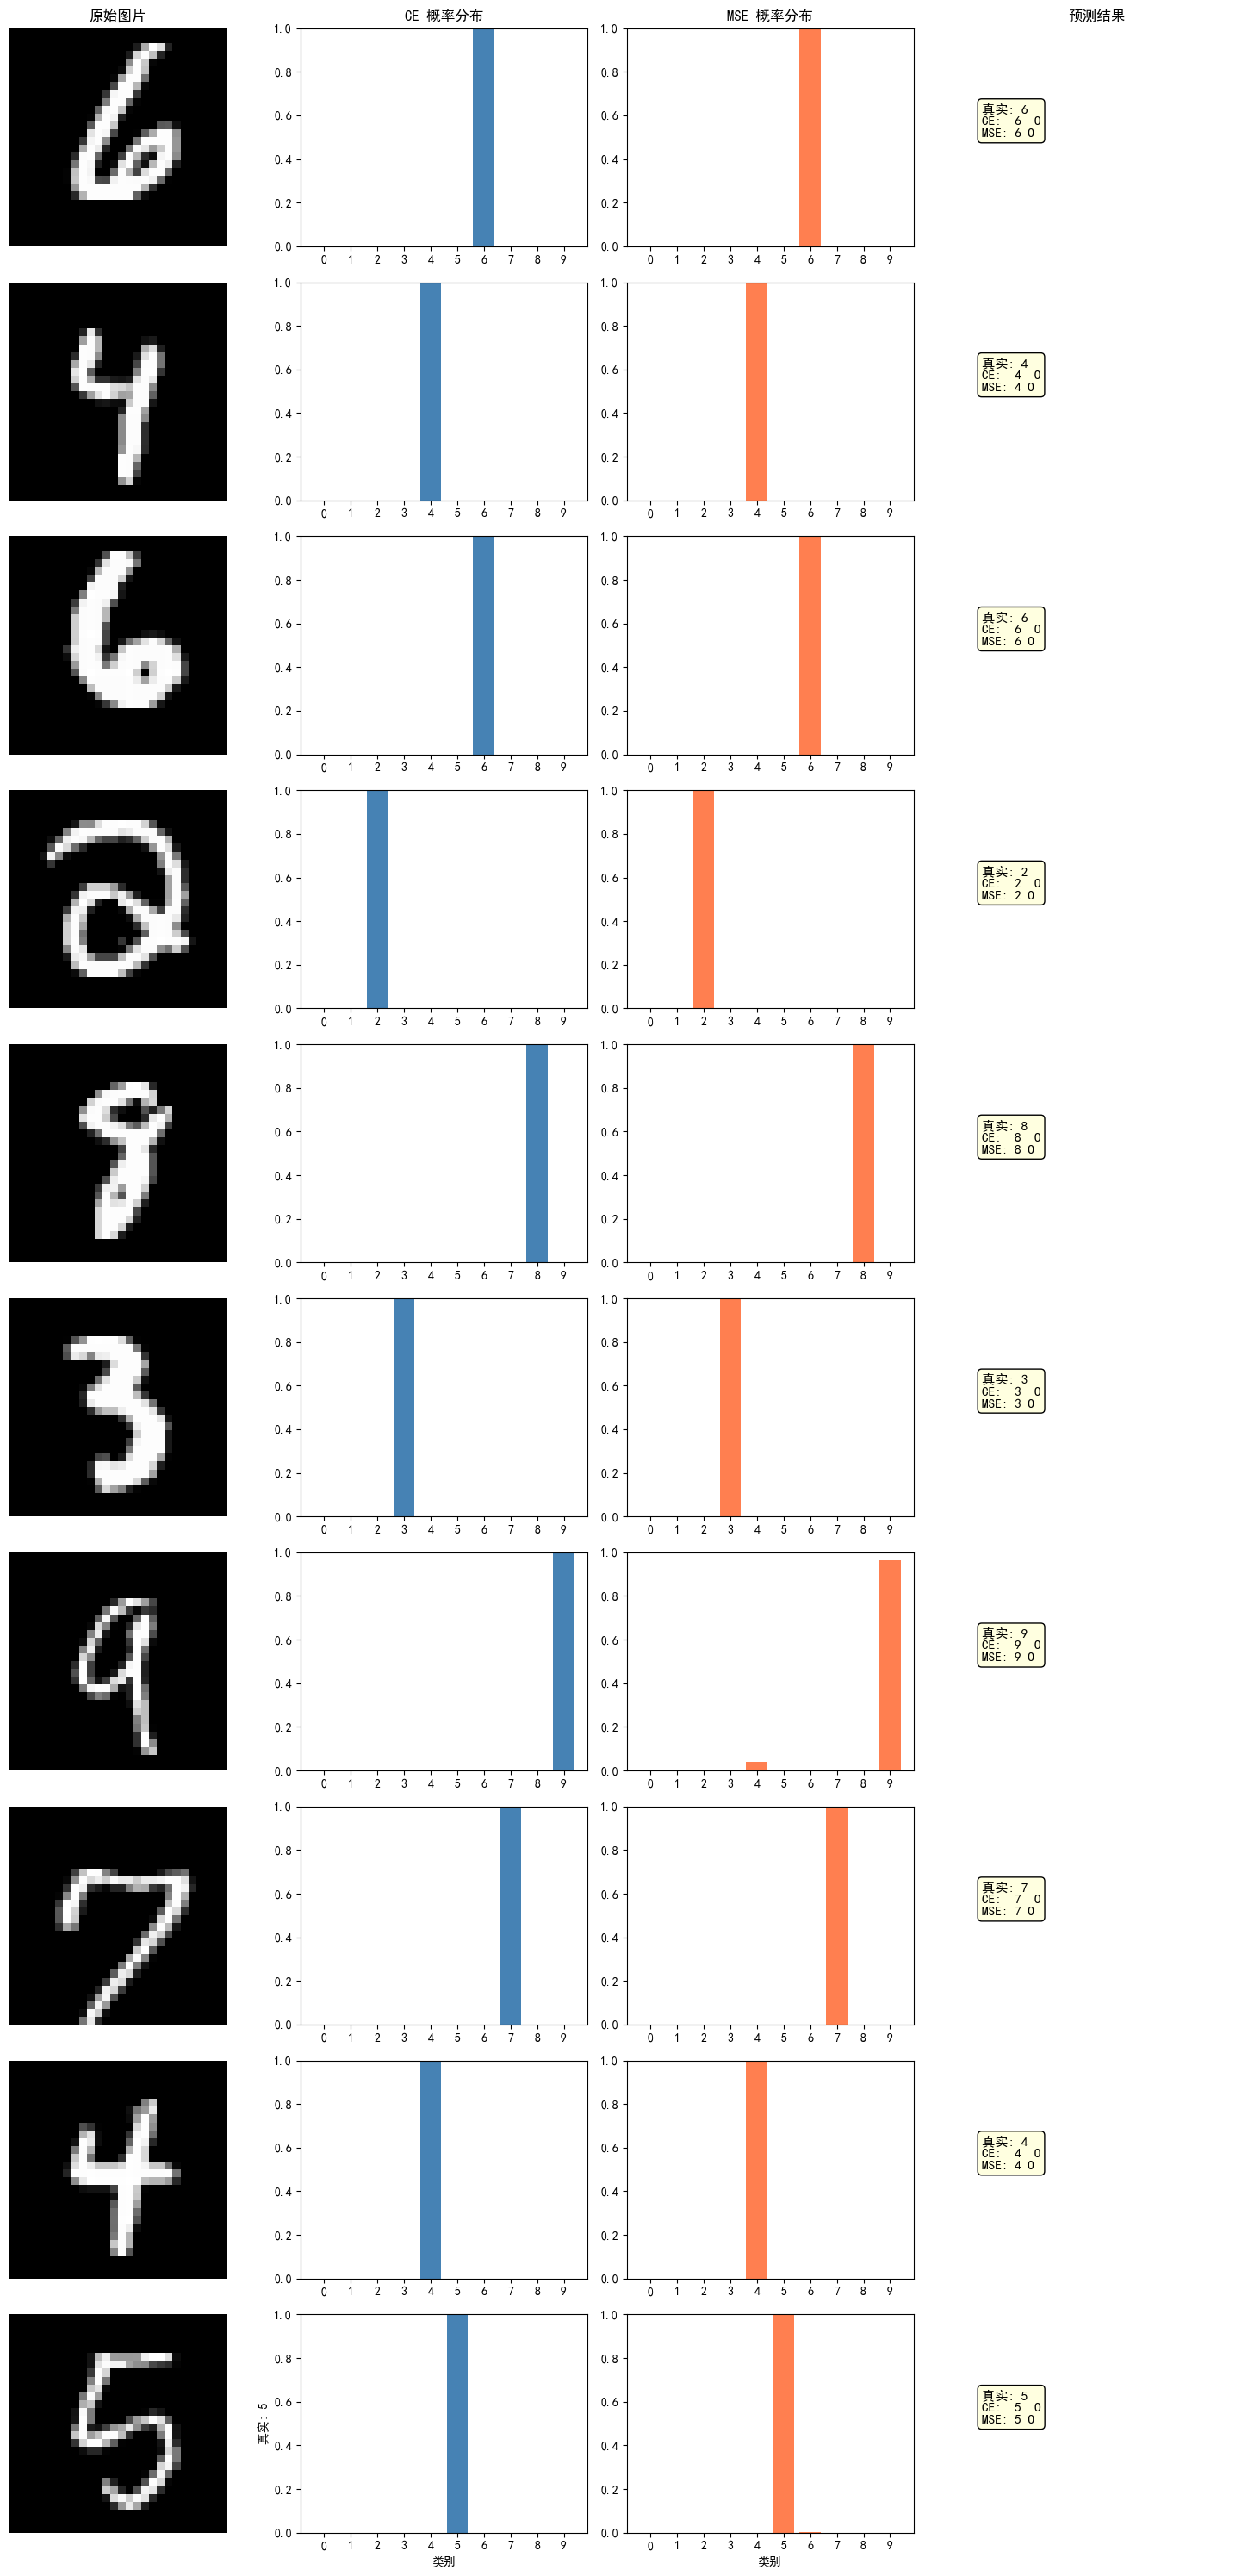

CE 模型错误:  0/10
MSE 模型错误: 0/10
两模型一致:   10/10


In [4]:
# ============================================================
# 单元格 4：加载保存的最优模型进行推理预测
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'SimSun']
plt.rcParams['axes.unicode_minus'] = False

# ==================== 1. 加载最优模型 ====================
# 使用 Trainer 的 load_best 方法加载已保存的 checkpoint
trainer_ce.load_best()
trainer_mse.load_best()

# ==================== 2. 整体准确率验证 ====================
with torch.no_grad():
    acc_ce  = trainer_ce._evaluate()[1]
    acc_mse = trainer_mse._evaluate()[1]

print(f"\n加载后评估准确率:")
print(f"  CE 模型:  {acc_ce:.2f}%")
print(f"  MSE 模型: {acc_mse:.2f}%")

# ==================== 3. 随机样本可视化 ====================
num_samples = 10
indices = np.random.choice(len(test_dataset), num_samples, replace=False)

device = trainer_ce.device
x_sample = test_dataset.images[indices].to(device)
y_true = test_dataset.labels[indices].numpy()

with torch.no_grad():
    pred_ce  = trainer_ce.net(x_sample).max(1)[1].cpu().numpy()
    pred_mse = trainer_mse.net(x_sample).max(1)[1].cpu().numpy()

# 原始图像（需从 Tensor 恢复为 numpy 用于显示）
img_sample = test_dataset.images[indices].cpu().numpy().reshape(-1, 28, 28)

plt.figure(figsize=(15, 3 * num_samples))
for i in range(num_samples):
    plt.subplot(num_samples, 4, i * 4 + 1)
    plt.imshow(img_sample[i], cmap='gray')
    plt.axis('off')
    if i == 0: plt.title('原始图片')

    plt.subplot(num_samples, 4, i * 4 + 2)
    with torch.no_grad():
        probs_ce = torch.softmax(trainer_ce.net(x_sample[i].unsqueeze(0)), dim=1)[0].cpu().numpy()
    plt.bar(range(10), probs_ce, color='steelblue')
    plt.ylim(0, 1); plt.xticks(range(10))
    if i == 0: plt.title('CE 概率分布')
    if i == num_samples - 1:
        plt.xlabel('类别'); plt.ylabel('真实: %d' % y_true[i])

    plt.subplot(num_samples, 4, i * 4 + 3)
    with torch.no_grad():
        probs_mse = trainer_mse.net(x_sample[i].unsqueeze(0))[0].cpu().numpy()
    plt.bar(range(10), probs_mse, color='coral')
    plt.ylim(0, 1); plt.xticks(range(10))
    if i == 0: plt.title('MSE 概率分布')
    if i == num_samples - 1: plt.xlabel('类别')

    plt.subplot(num_samples, 4, i * 4 + 4)
    is_ce_correct  = 'O' if pred_ce[i]  == y_true[i] else 'X'
    is_mse_correct = 'O' if pred_mse[i] == y_true[i] else 'X'
    info = (f"真实: {y_true[i]}\nCE:  {pred_ce[i]}  {is_ce_correct}\n"
            f"MSE: {pred_mse[i]} {is_mse_correct}")
    plt.text(0.1, 0.5, info, fontsize=11, transform=plt.gca().transAxes,
             bbox=dict(boxstyle='round', facecolor='lightyellow'))
    plt.axis('off')
    if i == 0: plt.title('预测结果')

plt.tight_layout()
plt.show()

# 统计
ce_errors  = (pred_ce  != y_true).sum()
mse_errors = (pred_mse != y_true).sum()
agree = (pred_ce == pred_mse).sum()
print(f"CE 模型错误:  {ce_errors}/{num_samples}")
print(f"MSE 模型错误: {mse_errors}/{num_samples}")
print(f"两模型一致:   {agree}/{num_samples}")


# 模型训练与验证完整过程总结

## 一、数据准备（单元格 1）
- **数据集**：MNIST 手写数字（28×28 灰度图，10 类 0~9）
- **数据规模**：60,000 训练样本 + 10,000 测试样本
- **加载方式**：手动解析 IDX 二进制格式（`struct`），用 `tqdm` 展示逐张图片 / 逐标签的加载进度
- **输出**：`train_images`(60000,28,28)、`train_labels`(60000,)、`test_images`(10000,28,28)、`test_labels`(10000,)

## 二、数据处理与网络定义（单元格 2）
- **预处理**：图像归一化到 [0,1] → 展平为 784 维向量 → 转为 PyTorch Tensor
- **DataLoader**：`batch_size=64`，训练集打乱顺序，测试集不打乱
- **网络结构**：三层全连接网络 `784 → 512(ReLU) → 256(ReLU) → 10`
- **总参数量**：535,818（fc1 占 401,920，fc2 占 131,328，fc3 占 2,570）
- **损失函数**：`CrossEntropyLoss`（内部含 Softmax，输出层不加）
- **优化器**：Adam（lr=0.001）
- **设备**：CUDA GPU

## 三、训练与自动保存（单元格 2 & 3）
- **训练循环**：10 个 Epoch，每个 epoch 遍历 938 个 batch
- **进度展示**：`tqdm` 实时显示每个 batch 的 Loss 和 Acc
- **最优模型保存**：每次测试准确率提升时自动覆盖保存（`torch.save`）
  - 保存内容：模型参数、优化器状态、epoch、测试准确率
  - 保存路径：`checkpoints/best_model_ce.pth` 和 `checkpoints/best_model_mse.pth`

## 四、交叉熵 vs MSE 对比实验（单元格 3）
| 对比项 | CrossEntropyLoss | MSELoss |
|--------|:----------------:|:-------:|
| 输出层 | 原始 logits（不加 Softmax） | 需要加 Softmax 转概率 |
| 标签格式 | 整数索引 (0~9) | one-hot 编码 |
| 最佳测试准确率 | 98.08% | 98.12% |
| Loss 数值范围 | ~0.01~0.2（含 log） | ~0.001~0.01（平方差） |
| 收敛速度 | 略快（第 1 epoch 96.75%） | 稍慢（第 1 epoch 96.62%） |

**结论**：对于 MNIST 分类任务，两种损失函数均能有效收敛，准确率接近。但 CrossEntropyLoss 理论上更适合分类任务（梯度与置信度成比例），且使用更简便（无需手动转换标签格式）。

## 五、模型加载与推理演示（单元格 4）
- **加载流程**：重新定义模型类 → 实例化 → `load_state_dict()` 加载参数
- **验证准确率**：与训练时保存的最佳准确率一致
- **可视化**：随机抽取 10 张测试图片，展示 CE / MSE 模型的概率分布柱状图与预测结果
- **整体流程**：
  ```
  数据加载 → 预处理 → 定义网络 → 训练（自动保存最优）→ 加载模型 → 推理预测
  ```

## 六、关键超参数记录
| 超参数 | 取值 | 说明 |
|--------|:----:|------|
| batch_size | 64 | 每个 batch 样本数 |
| learning_rate | 0.001 | Adam 优化器学习率 |
| num_epochs | 10 | 完整遍历训练集次数 |
| hidden1 | 512 | 第一层隐藏单元数 |
| hidden2 | 256 | 第二层隐藏单元数 |
| input_dim | 784 | 输入特征数 (28×28) |
| num_classes | 10 | 输出类别数 |
